# A Vanilla Training Loop for Linear Regression

This is an optional practice notebook for lecture 1: it is not graded and not part of assignment 1.
Suggested order: mean squared error, then categorical cross-entropy, then this notebook, which builds on the MSE notebook.
It reproduces the vanilla training loop from the lecture slides, including the numbers, so you can experiment with it.

We solve a *regression* problem with a linear model.
The training set consists of $N$ inputs $x_n \in \mathbb{R}$ and labels $y_n \in \mathbb{R}$.
The goal is to find a function $f(x)$ that fits the data.
We use a linear model with two parameters, a weight $w$ and a bias $b$,

$$
f_{\boldsymbol{\theta}}(x) = w x + b, \qquad \boldsymbol{\theta} = (w, b),
$$

and we measure the fit with the mean squared error (MSE) over the training examples.

In [1]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np

In [2]:
def linear_model(x, w, b):
    """Return the predictions of the line `w * x + b` at the inputs `x`."""
    return w * x + b


def mse(y, y_pred):
    """Return the mean squared error between labels and predictions."""
    return np.mean((y - y_pred) ** 2)

## 1. Dataset creation

We draw the data from a line, $y = 2x + 3$, plus Gaussian noise with standard deviation $1.5$.
This is a toy example: we know the data-generating process, so we can sample as many examples as we like.
A real machine learning problem gives **no access** to this process.
For example, nobody knows the function that maps the pixels of an image to the object it shows.
The training algorithm below only ever sees the samples.

We draw $N_\text{train} = 60$ training examples and $N_\text{test} = 20$ test examples, with a fixed seed so that the outputs match the slides.

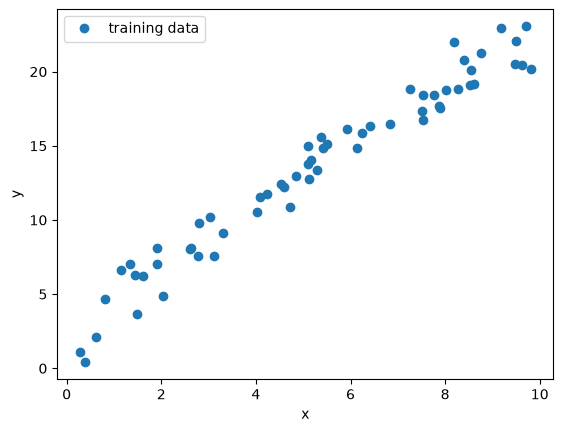

In [3]:
rng = np.random.default_rng(1)
N_train = 60
N_test = 20


def get_dataset(num_examples):
    """Return inputs on [0, 10] and noisy labels from the line y = 2x + 3.

    Args:
        num_examples: Number of examples to draw.

    Returns:
        A tuple `(x, y)` of arrays with `num_examples` entries each.
    """
    x = rng.uniform(0, 10, num_examples)
    y = 2 * x + 3 + rng.normal(0, 1.5, num_examples)
    return x, y


x_train, y_train = get_dataset(N_train)
x_test, y_test = get_dataset(N_test)

plt.plot(x_train, y_train, "o", label="training data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 2. Training

Training means finding parameters that fit the training data well.
One idea is to start from a guess and check how the corresponding line performs on the training set.
Let's start with $w = 1$ and $b = 0$.

MSE = 77.33


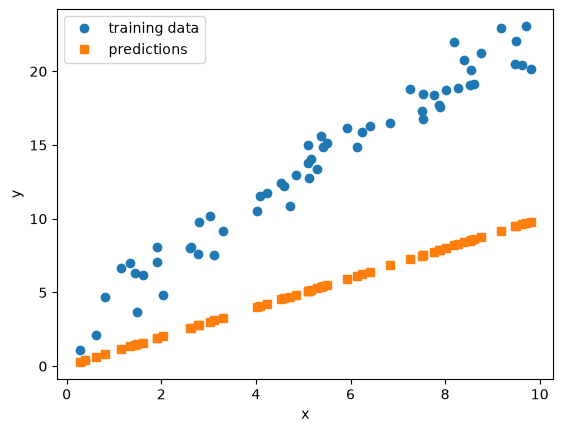

In [4]:
w, b = 1.0, 0.0

y_pred = linear_model(x_train, w, b)
print(f"MSE = {mse(y_train, y_pred):.2f}")

plt.plot(x_train, y_train, "o", label="training data")
plt.plot(x_train, y_pred, "s", label="predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

A poor fit.
To improve it, let's probe every small step of $\pm 0.05$ (or $0$) in each parameter and see how the MSE changes.

In [5]:
step = 0.05
deltas = (step, 0, -step)
moves = [move for move in product(deltas, repeat=2) if move != (0, 0)]

for dw, db in moves:
    y_pred = linear_model(x_train, w + dw, b + db)
    print(f"dw = {dw:+.2f}, db = {db:+.2f}: MSE = {mse(y_train, y_pred):.2f}")

dw = +0.05, db = +0.05: MSE = 71.46
dw = +0.05, db = +0.00: MSE = 72.25
dw = +0.05, db = -0.05: MSE = 73.04
dw = +0.00, db = +0.05: MSE = 76.52
dw = +0.00, db = -0.05: MSE = 78.15
dw = -0.05, db = +0.05: MSE = 81.75
dw = -0.05, db = +0.00: MSE = 82.60
dw = -0.05, db = -0.05: MSE = 83.44


Increasing both parameters a little gives the best MSE, so we move there.
One such round of probe-and-step is an *epoch*.
Let's write a function for it.

In [6]:
def update_parameters(w, b, x, y, step=0.05):
    """Probe every step of +-`step` (or 0) in `w` and `b` and return the best candidate.

    Args:
        w: Current weight.
        b: Current bias.
        x: Training inputs.
        y: Training labels.
        step: Size of the probing step.

    Returns:
        A tuple `(mse_best, w_best, b_best)` of the smallest MSE among the eight
        candidates and the parameters that achieve it.
    """
    deltas = (step, 0, -step)
    moves = [move for move in product(deltas, repeat=2) if move != (0, 0)]
    candidates = [(mse(y, linear_model(x, w + dw, b + db)), w + dw, b + db) for dw, db in moves]
    return min(candidates)


mse_best, w, b = update_parameters(w, b, x_train, y_train)
print(f"epoch 1: w = {w:.2f}, b = {b:.2f}, MSE = {mse_best:.2f}")

epoch 1: w = 1.05, b = 0.05, MSE = 71.46


The line is slightly better, but we are not done.
Let's repeat the game until no probe improves the MSE any more.

final (epoch 47): w = 2.10, b = 2.35, MSE = 1.52


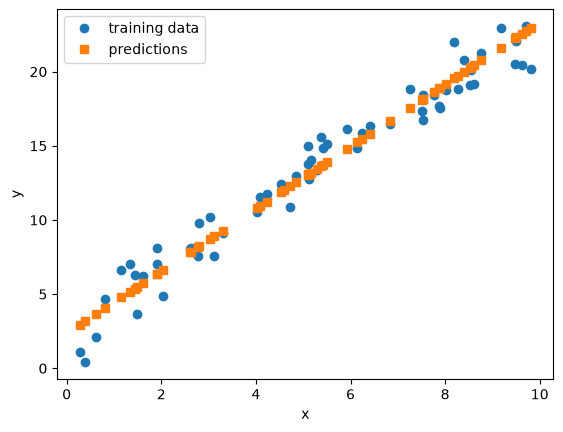

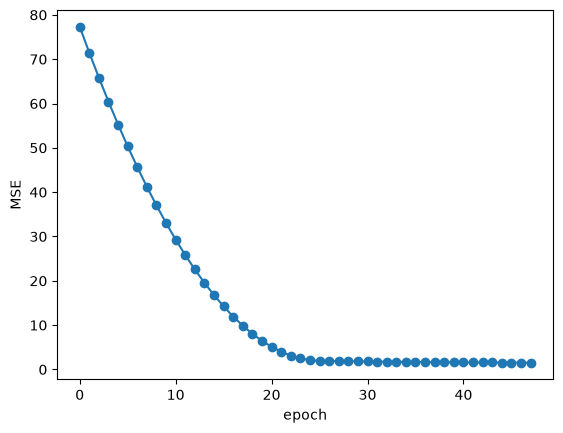

In [7]:
def training_loop(w, b, x, y, max_epochs=300):
    """Run probe-and-step epochs until the MSE stops improving.

    Args:
        w: Initial weight.
        b: Initial bias.
        x: Training inputs.
        y: Training labels.
        max_epochs: Upper limit on the number of epochs.

    Returns:
        A tuple `(w, b, mse_history)` with the final parameters and the MSE
        after every epoch, starting with the initial one.
    """
    mse_history = [mse(y, linear_model(x, w, b))]
    for _ in range(max_epochs):
        mse_best, w_best, b_best = update_parameters(w, b, x, y)
        if mse_best >= mse_history[-1]:
            break
        w, b = w_best, b_best
        mse_history.append(mse_best)
    return w, b, mse_history


w, b, mse_history = training_loop(1.0, 0.0, x_train, y_train)
print(f"final (epoch {len(mse_history) - 1}): w = {w:.2f}, b = {b:.2f}, MSE = {mse_history[-1]:.2f}")

y_pred = linear_model(x_train, w, b)
plt.plot(x_train, y_train, "o", label="training data")
plt.plot(x_train, y_pred, "s", label="predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

plt.plot(mse_history, "o-")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.show()

The MSE drops quickly at first, then flattens once the line matches the data.
What remains is the noise, which no line can fit.

## 3. Test

The line fits the training data well.
But what about data the model has never seen?
Let's evaluate it on the test set.

test MSE = 2.19


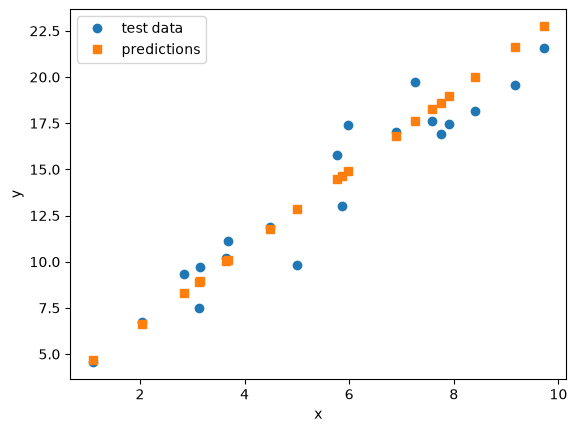

In [8]:
y_pred = linear_model(x_test, w, b)
print(f"test MSE = {mse(y_test, y_pred):.2f}")

plt.plot(x_test, y_test, "o", label="test data")
plt.plot(x_test, y_pred, "s", label="predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

The test MSE is slightly worse than the training MSE, as is typical, but close: the model generalizes.

## Conclusion

We trained a linear regressor by trying small changes to the parameters and keeping the change that decreases the MSE the most.
This works for two parameters, but the number of probes grows exponentially with the number of parameters.
In the next lectures, the direction of steepest decrease will come from the *gradient* instead, from a single computation.

Things to try: change the seed, the step size, the noise level, or the starting parameters, and watch how the number of epochs and the final MSE change.